In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax.training.train_state import TrainState

from flightning import FLIGHTNING_PATH
from flightning.algos import bptt
from flightning.envs import HoveringStateEnv, rollout
from flightning.envs.wrappers import MinMaxObservationWrapper
from flightning.modules import MLP

%matplotlib inline

2025-12-01 15:31:21.124549: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


# Training a State-based Quadrotor Policy With BPTT

## Seed it

In [2]:
seed = 0
key = jax.random.key(seed)
key_init, key_bptt = jax.random.split(key, 2)

## Setup the Training Environment

In [3]:
drone_path = FLIGHTNING_PATH + "/objects/quadrotor_files/example_quad.yaml"
dt = 0.02

env = HoveringStateEnv(
    max_steps_in_episode=6 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.1,
    yaw_scale=1.0,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
    reward_sharpness=5.0,
    action_penalty_weight=0.5,
)
env = MinMaxObservationWrapper(env)

# get dims
action_dim = env.action_space.shape[0]
obs_dim = env.observation_space.shape[0]

## Define the Policy Network

In [4]:
policy_net = MLP(
    [obs_dim, 512, 512,512, action_dim],
    initial_scale=0.01,
    action_bias=env.hovering_action,
)
policy_params = policy_net.initialize(key_init)

## Setup the Optimizer and Train State

In [5]:
from orbax.checkpoint import PyTreeCheckpointer
restore_chkpoint=True
if restore_chkpoint:
    ckptr = PyTreeCheckpointer()
    path = FLIGHTNING_PATH + "/../examples/saved_params"
    params_loaded = ckptr.restore(path)
    
    print("Loaded params")
    print(params_loaded['params']['Dense_0']['kernel'])  

Loaded params
[[-0.6948239  -0.07877512 -0.52178985 ... -0.24857341 -0.2043415
  -0.26984164]
 [-0.08475011  0.03231514 -0.3217605  ...  0.0333855  -0.43006864
   0.22135453]
 [ 0.36951694  0.3977817   0.34850708 ...  0.27459028  0.3876827
   0.05097894]
 ...
 [-0.1321559   0.16600387  0.17113416 ... -0.07149332  0.09087195
  -0.12687711]
 [-0.02833555 -0.07776482 -0.3067995  ...  0.0843055   0.06968112
   0.2977393 ]
 [-0.12215768 -0.06453034  0.06265672 ... -0.12733844  0.02841514
   0.16477089]]


/home/yanrui/miniconda3/envs/flightning6/lib/python3.9/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


In [6]:
N = 1000
scheduler = optax.cosine_decay_schedule(1e-2, N)
tx = optax.adam(scheduler)
if restore_chkpoint:
    print("Reloading params")
    train_state = TrainState.create(
    apply_fn=policy_net.apply, params=params_loaded, tx=tx
)
else:
    print("new params")
    train_state = TrainState.create(
        apply_fn=policy_net.apply, params=policy_params, tx=tx
    )

Reloading params


## Initial Rollout

In [7]:
def get_rollouts(env, policy, num_rollouts, key):
    parallel_rollout = jax.vmap(rollout, in_axes=(None, 0, None))
    rollout_keys = jax.random.split(key, num_rollouts)
    transitions = parallel_rollout(env, rollout_keys, policy)
    return transitions


def policy(obs, key):
    return train_state.apply_fn(train_state.params, obs)

transitions = get_rollouts(env, policy, 10, jax.random.key(3))

/home/yanrui/tempstorage5/rpg_flightning/flightning/envs/hovering_state_env.py:545: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


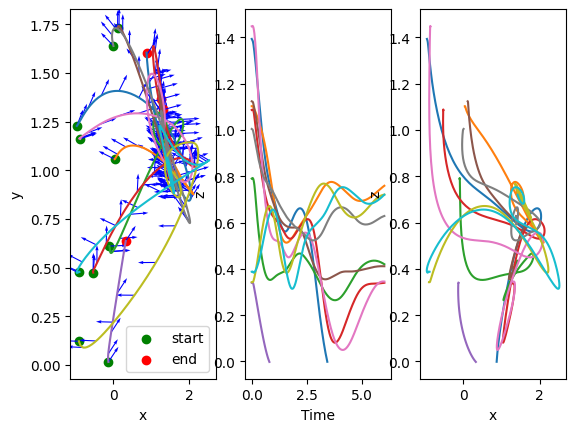

In [8]:
env.plot_trajectories(transitions)

## Train the Policy Using BPTT

In [9]:
time_start = time.time()
res_dict = bptt.train(
    env,
    train_state,
    num_epochs=1000,
    num_steps_per_epoch=env.max_steps_in_episode,
    num_envs=200,
    key=key_bptt,
)
time_train = time.time() - time_start
print(f"Training time: {time_train}")

Episode: 0, Grad max: 193.0802
Episode: 0, Loss: 317.19
Episode: 10, Grad max: 4.1878
Episode: 10, Loss: 78.67
Episode: 20, Grad max: 2.3600
Episode: 20, Loss: 79.07
Episode: 30, Grad max: 2.7036
Episode: 30, Loss: 77.67
Episode: 40, Grad max: 4.5984
Episode: 40, Loss: 77.14
Episode: 50, Grad max: 5.7053
Episode: 50, Loss: 77.93
Episode: 60, Grad max: 4.2858
Episode: 60, Loss: 74.40
Episode: 70, Grad max: 2.4849
Episode: 70, Loss: 74.41
Episode: 80, Grad max: 1.8273
Episode: 80, Loss: 75.48
Episode: 90, Grad max: 3.4361
Episode: 90, Loss: 80.03
Episode: 100, Grad max: 4.4730
Episode: 100, Loss: 80.11
Episode: 110, Grad max: 1.9501
Episode: 110, Loss: 80.28
Episode: 120, Grad max: 1.3692
Episode: 120, Loss: 74.10
Episode: 130, Grad max: 1.8913
Episode: 130, Loss: 81.28
Episode: 140, Grad max: 2.0296
Episode: 140, Loss: 81.84
Episode: 150, Grad max: 1.3985
Episode: 150, Loss: 77.66
Episode: 160, Grad max: 2.2394
Episode: 160, Loss: 81.44
Episode: 170, Grad max: 3.7919
Episode: 170, Loss:

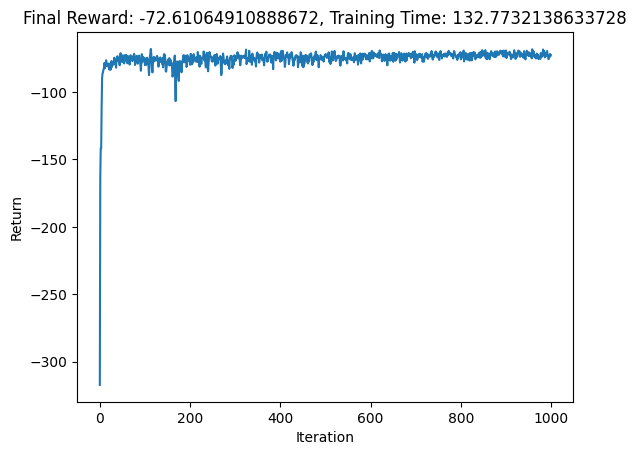

In [10]:
rewards = -res_dict["metrics"]
plt.plot(rewards)
plt.title(f"Final Reward: {rewards[-1]}, Training Time: {time_train}")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.show()

## Evaluate the Trained Policy

In [11]:
new_train_state = res_dict["runner_state"].train_state

def policy_trained(obs, key):
    return train_state.apply_fn(new_train_state.params, obs)

In [12]:
env_eval = HoveringStateEnv(
    max_steps_in_episode=5 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.1,
    yaw_scale=1.0,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
)
env_eval = MinMaxObservationWrapper(env_eval)
transitions_eval = get_rollouts(env_eval, policy_trained, 20, jax.random.key(3))

/home/yanrui/tempstorage5/rpg_flightning/flightning/envs/hovering_state_env.py:545: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


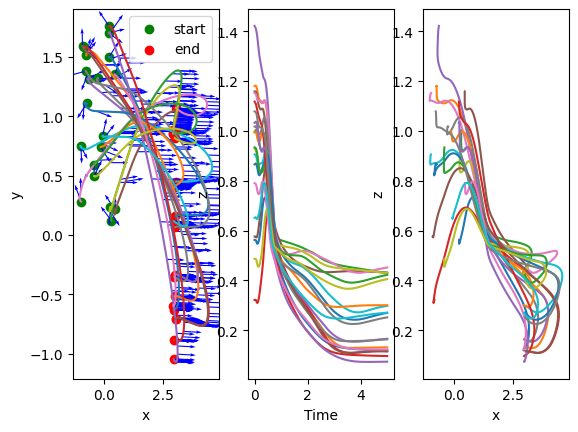

In [13]:
env_eval.plot_trajectories(transitions_eval)

In [14]:
from orbax.checkpoint import PyTreeCheckpointer
path = FLIGHTNING_PATH + "/../examples/saved_params"
ckptr = PyTreeCheckpointer()
ckptr.save(path, new_train_state.params)

ValueError: Destination /home/yanrui/tempstorage5/rpg_flightning/flightning/../examples/saved_params already exists.

In [ ]:
transitions_eval.state.quadrotor_state.v[3][0,:]